In [1]:
import numpy as np
from sim_library.simulation import simulate_pulses_p_dist, simulate_pulses_single_atom
from sim_library.sequences import gen_resonant_pm_seq, gen_offresonant_pm_seq, UpPulse, DownPulse, FreeEvolution, PulseSequence, gen_MDFE_seq
from sim_library.plotting import plot_state_trajectories, plot_bloch, plot_hist
from scipy.constants import hbar, pi
from sim_library.constants import k_eff, dR, m, omega_eg
import matplotlib.pyplot as plt

### EX(1,0)

In [39]:
#swaps qubit 1 and qubit 2
#i.e |10> --> |01> so |n=2> --> |n=1>

p_min = 0
p_max = 8
basis = np.arange(p_min, p_max + 1)

rabi_freq = 2*pi*10000000
rabi_time = 2*pi/rabi_freq

time_steps = 1

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
# initial_state[2] = 1
initial_state[1] = 1
initial_state[3] = 1
initial_state[4] = 1

initial_state = initial_state/ np.linalg.norm(initial_state)

omega_time = 2*pi/omega_eg #chosen to be much larger than recoil shift

print("initial wave func")
print(initial_state)
print("probs:")
print(np.round(np.square(np.abs(initial_state)), 5))

exchange = PulseSequence()

freevolve_fivefour = FreeEvolution(laser_det=(np.full(time_steps, omega_eg/2)), duration=5*omega_time/4) #5pi/4
freevolve_onetwo = FreeEvolution(laser_det=(np.full(time_steps, omega_eg/2)), duration=omega_time/2) #pi/2
MDFE_quartpi = gen_MDFE_seq(free_time=pi/(4*dR), rabi_freq=rabi_freq, time_steps=time_steps)
halfpi_pulse1 = DownPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, pi/4), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/4)
halfpi_pulse2 = DownPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, pi), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/4)

exchange.add_pulses([freevolve_fivefour, halfpi_pulse1, MDFE_quartpi, halfpi_pulse2, freevolve_onetwo])

wave_func, times = simulate_pulses_single_atom(pulse_seq= exchange, basis= basis, initial_state=initial_state, d_shift=0)

print("final wave func:")
print(wave_func[-1,:])
print("probs:")
print(np.round(np.square(np.abs(wave_func[-1,:])), 3))



initial wave func
[0.        +0.j 0.57735027+0.j 0.        +0.j 0.57735027+0.j
 0.57735027+0.j 0.        +0.j 0.        +0.j 0.        +0.j
 0.        +0.j]
probs:
[0.      0.33333 0.      0.33333 0.33333 0.      0.      0.      0.     ]
final wave func:
[ 2.86409340e-15-2.85678847e-15j  1.83714846e-02-2.62835831e-03j
 -3.28008420e-02-5.76903264e-01j -1.34793133e-01-5.10865489e-01j
  5.91980060e-01-1.89916253e-01j  6.98807146e-03+1.74638543e-03j
  6.91464980e-03+1.14137867e-03j  0.00000000e+00+0.00000000e+00j
  0.00000000e+00+0.00000000e+00j]
probs:
[0.    0.    0.334 0.279 0.387 0.    0.    0.    0.   ]


initial wave func
[0.        +0.j 0.40824829+0.j 0.        +0.j 0.40824829+0.j
 0.40824829+0.j 0.40824829+0.j 0.        +0.j 0.        +0.j
 0.        +0.j 0.40824829+0.j 0.        +0.j 0.        +0.j
 0.        +0.j 0.40824829+0.j 0.        +0.j 0.        +0.j
 0.        +0.j]
probs:
[0.      0.16667 0.      0.16667 0.16667 0.16667 0.      0.      0.
 0.16667 0.      0.      0.      0.16667 0.      0.      0.     ]
final wave func:
[-0.   -0.j    -0.   -0.j    -0.001-0.408j -0.001-0.408j  0.408-0.j
 -0.   -0.j    -0.   -0.408j  0.   +0.j     0.   +0.j     0.   -0.j
 -0.   -0.408j  0.   -0.j     0.   +0.j     0.   -0.j    -0.001-0.408j
 -0.   +0.j    -0.   +0.j   ]
probs:
[0.    0.    0.167 0.167 0.167 0.    0.167 0.    0.    0.    0.167 0.
 0.    0.    0.167 0.    0.   ]


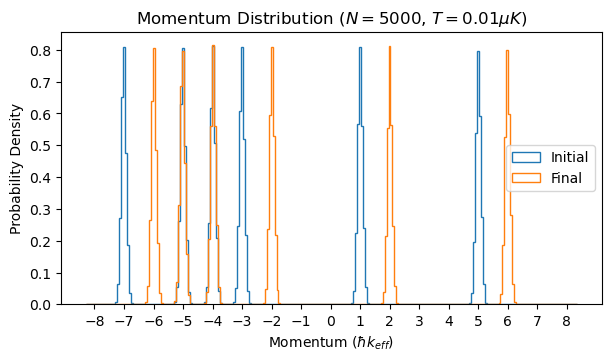

In [21]:
# plotting momentum distribution
N = 5000
Temp = 0.01e-6

p_min = -8
p_max = 8
basis = np.arange(p_min, p_max + 1)

rabi_freq = 2*pi*1000000000000
rabi_time = 2*pi/rabi_freq

time_steps = 1

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
initial_state[13] = 1 
initial_state[9] = 1
initial_state[5] = 1
initial_state[1] = 1
initial_state[3] = 1
initial_state[4] = 1

initial_state = initial_state/ np.linalg.norm(initial_state)

omega_time = 2*pi/omega_eg #chosen to be much larger than recoil shift

print("initial wave func")
print(initial_state)
print("probs:")
print(np.round(np.square(np.abs(initial_state)), 5))

exchange = PulseSequence()

freevolve_fivefour = FreeEvolution(laser_det=(np.full(time_steps, omega_eg/2)), duration=5*omega_time/4) #5pi/4
freevolve_onetwo = FreeEvolution(laser_det=(np.full(time_steps, omega_eg/2)), duration=omega_time/2) #pi/2
MDFE_quartpi = gen_MDFE_seq(free_time=pi/(4*dR), rabi_freq=rabi_freq, time_steps=time_steps)
halfpi_pulse1 = DownPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, pi/4), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/4)
halfpi_pulse2 = DownPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, pi), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/4)

exchange.add_pulses([freevolve_fivefour, halfpi_pulse1, MDFE_quartpi, halfpi_pulse2, freevolve_onetwo])

# exchange_fast = PulseSequence()

# freevolve_fivefour = FreeEvolution(laser_det=(np.full(1, omega_eg/2)), duration=5*omega_time/4) #5pi/4
# freevolve_onetwo = FreeEvolution(laser_det=(np.full(1, omega_eg/2)), duration=omega_time/2) #pi/2
# MDFE_quartpi = gen_MDFE_seq(free_time=pi/(4*dR), rabi_freq=rabi_freq, time_steps=1)
# halfpi_pulse1 = DownPulse(laser_det=np.full(1, dR), phase=np.full(1, pi/4), rabi_freq=np.full(1, rabi_freq), duration=rabi_time/4)
# halfpi_pulse2 = DownPulse(laser_det=np.full(1, dR), phase=np.full(1, pi), rabi_freq=np.full(1, rabi_freq), duration=rabi_time/4)

# exchange_fast.add_pulses([freevolve_fivefour, halfpi_pulse1, MDFE_quartpi, halfpi_pulse2, freevolve_onetwo])



wave_func, times = simulate_pulses_single_atom(pulse_seq= exchange, basis= basis, initial_state=initial_state, d_shift=0)

moms, fracs, _ = simulate_pulses_p_dist(pulse_seq=exchange, Temp=Temp, no_atoms=N, basis=basis, initial_state=initial_state)

print("final wave func:")
print(np.round(wave_func[-1,:], 3))
print("probs:")
print(np.round(np.square(np.abs(wave_func[-1,:])), 3))

moms = moms/(hbar*k_eff)

probs = np.abs(wave_func)**2

# fig1, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 7.5), layout= 'constrained')
fig1, ax2 = plt.subplots(1, 1, figsize=(6, 3.5), layout= 'constrained')

# plot_state_trajectories(ax= ax1, wavefunc= probs, time_array= times, basis= basis, title= r'State trajectories ($\delta_D = 0$)', contains_title= True)
plot_hist(ax= ax2, mom_vals= moms, fracs= fracs, n_bins= 250, n_atoms= N, temp=Temp, contains_title= True)

ax2.set_xticks(basis);

### anti CNOT

In [ ]:
# plotting momentum distribution
N = 5000
Temp = 0.01e-6

p_min = -8
p_max = 8
basis = np.arange(p_min, p_max + 1)

rabi_freq = 2*pi*1000000000000
rabi_time = 2*pi/rabi_freq

time_steps = 1

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
initial_state[1] = -1j 
initial_state[10] = 1
initial_state[11] = 1
initial_state[13] = 1
initial_state[9] = 1
initial_state[8] = 1
initial_state[5] = 1

initial_state = initial_state/ np.linalg.norm(initial_state)

omega_time = 2*pi/omega_eg #chosen to be much larger than recoil shift

print("initial wave func")
print(initial_state)
print("probs:")
print(np.round(np.square(np.abs(initial_state)), 5))

antiCNOT = PulseSequence()

freevolve_fivefour = FreeEvolution(laser_det=(np.full(time_steps, omega_eg/2)), duration=5*omega_time/4) #5pi/4
freevolve_threetwo = FreeEvolution(laser_det=(np.full(time_steps, omega_eg/2)), duration=3*omega_time/2) #pi/2
MDFE_quartpi = gen_MDFE_seq(free_time=pi/(4*dR), rabi_freq=rabi_freq, time_steps=time_steps)
halfpi_pulse1 = UpPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, pi/4), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/4)
halfpi_pulse2 = UpPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/4)
twopi_pulse = UpPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time)

antiCNOT.add_pulses([freevolve_fivefour, halfpi_pulse1, MDFE_quartpi, halfpi_pulse2, freevolve_threetwo, twopi_pulse])


wave_func, times = simulate_pulses_single_atom(pulse_seq= antiCNOT, basis= basis, initial_state=initial_state, d_shift=0)

moms, fracs, _ = simulate_pulses_p_dist(pulse_seq= antiCNOT, Temp=Temp, no_atoms=N, basis=basis, initial_state=initial_state)

print("final wave func:")
print(np.round(wave_func[-1,:], 3))
print("probs:")
print(np.round(np.square(np.abs(wave_func[-1,:])), 3))

moms = moms/(hbar*k_eff)

probs = np.abs(wave_func)**2

# fig1, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 7.5), layout= 'constrained')
fig1, ax2 = plt.subplots(1, 1, figsize=(6, 3.5), layout= 'constrained')

# plot_state_trajectories(ax= ax1, wavefunc= probs, time_array= times, basis= basis, title= r'State trajectories ($\delta_D = 0$)', contains_title= True)
plot_hist(ax= ax2, mom_vals= moms, fracs= fracs, n_bins= 250, n_atoms= N, temp=Temp, contains_title= True)

ax2.set_xticks(basis);

initial wave func
[ 0.        +0.j         -0.        -0.37796447j  0.        +0.j
  0.        +0.j          0.        +0.j          0.37796447+0.j
  0.        +0.j          0.        +0.j          0.37796447+0.j
  0.37796447+0.j          0.37796447+0.j          0.37796447+0.j
  0.        +0.j          0.37796447+0.j          0.        +0.j
  0.        +0.j          0.        +0.j        ]
probs:
[0.      0.14286 0.      0.      0.      0.14286 0.      0.      0.14286
 0.14286 0.14286 0.14286 0.      0.14286 0.      0.      0.     ]
